In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import oggm.cfg as cfg
from oggm import utils, workflow, tasks
from oggm.shop import gcm_climate
import seaborn as sns

In [3]:
# Initialise OGGM
cfg.initialize(logging_level='WARNING')
cfg.PATHS['working_dir'] = utils.gettempdir('OGGM_Runoff_GCM, reset=True')
cfg.PARAMS['store_model_geometry'] = True
cfg.PARAMS['store_fl_diagnostics'] = True

# Initialise gdirs and define RGI ID
base_url = 'https://cluster.klima.uni-bremen.de/~oggm/gdirs/oggm_v1.6/L3-L5_files/2023.3/elev_bands/W5E5_spinup/'
rgi_id = 'RGI60-06.00291'  
gdirs = workflow.init_glacier_directories([rgi_id], 
                                        from_prepro_level=5,
                                        prepro_base_url=base_url)

2025-04-10 19:42:58: oggm.cfg: Reading default parameters from the OGGM `params.cfg` configuration file.
2025-04-10 19:42:58: oggm.cfg: Multiprocessing switched OFF according to the parameter file.
2025-04-10 19:42:58: oggm.cfg: Multiprocessing: using slurm allocated processors (N=4)
2025-04-10 19:42:59: oggm.cfg: PARAMS['store_model_geometry'] changed from `False` to `True`.
2025-04-10 19:42:59: oggm.cfg: PARAMS['store_fl_diagnostics'] changed from `False` to `True`.
2025-04-10 19:42:59: oggm.workflow: init_glacier_directories from prepro level 5 on 1 glaciers.
2025-04-10 19:43:00: oggm.workflow: Execute entity tasks [gdir_from_prepro] on 1 glaciers


In [4]:
# Run a dynamic spinup from 2000-2019 for historical runoff. Helpful Tutorial here! https://tutorials.oggm.org/stable/notebooks/tutorials/dynamical_spinup.html.
workflow.execute_entity_task(
    tasks.run_with_hydro,
    gdirs,
    run_task=tasks.run_dynamic_spinup,
    spinup_start_yr=2000,
    output_filesuffix='_dynamic_runoff',
    ye=2019,  
    store_monthly_hydro=True,
    minimise_for='area',
)

2025-04-10 19:43:00: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers


[None]

In [5]:
# Load historical runoff
with xr.open_dataset(gdirs[0].get_filepath('model_diagnostics', filesuffix='_dynamic_runoff')) as ds:
    ds_hist = ds.isel(time=slice(0, -1)).load()

In [6]:
# Add the GCM data and define ssp scenarios
gcms = [
    'gfdl-esm4_r1i1p1f1', 
    'mpi-esm1-2-hr_r1i1p1f1', 
    'mri-esm2-0_r1i1p1f1', 
    'ipsl-cm6a-lr_r1i1p1f1', 
    'ukesm1-0-ll_r1i1p1f2']

scenarios = ['ssp126', 'ssp370', 'ssp585']

In [7]:
# Process GCM data
for gcm in gcms:
    for ssp in scenarios:
        workflow.execute_entity_task(
            gcm_climate.process_monthly_isimip_data,
            gdirs, 
            ssp=ssp,
            member=gcm,
            output_filesuffix=f'_ISIMIP3b_{gcm}_{ssp}'
        )

2025-04-10 19:43:05: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-10 19:43:06: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-10 19:43:07: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-10 19:43:09: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-10 19:43:10: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-10 19:43:11: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-10 19:43:12: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-10 19:43:13: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-10 19:43:14: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1 glaciers
2025-04-10 19:43:15: oggm.workflow: Execute entity tasks [process_monthly_isimip_data] on 1

In [8]:
# Run GCM projection with dynamic spinup
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}'
        workflow.execute_entity_task(
            tasks.run_with_hydro,
            gdirs,
            run_task=tasks.run_from_climate_data,
            climate_filename='gcm_data',
            climate_input_filesuffix=rid,
            output_filesuffix=f'{rid}_hydro',
            init_model_filesuffix='_dynamic_runoff', 
            ys=2020,
            ye=2100,
            store_monthly_hydro=True
        )

2025-04-10 19:43:27: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:28: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:29: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:30: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:30: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:31: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:32: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:32: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:33: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:34: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:35: oggm.workflow: Execute entity tasks [run_with_hydro] on 1 glaciers
2025-04-10 19:43:35: oggm.workfl

In [9]:
# Load GCM results
gcm_results = []
for gcm in gcms:
    for ssp in scenarios:
        rid = f'_ISIMIP3b_{gcm}_{ssp}_hydro'
        with xr.open_dataset(gdirs[0].get_filepath('model_diagnostics', filesuffix=rid)) as ds:
            ds_gcm = ds.isel(time=slice(0, -1)).load()
            ds_gcm = ds_gcm.assign_coords(GCM=gcm, SCENARIO=ssp)
            gcm_results.append(ds_gcm)
            
ds_gcm = xr.concat(gcm_results, dim='run')

In [10]:
# Process runoff after simulation
def process_runoff(ds):
    runoff_vars = ['melt_on_glacier', 'melt_off_glacier', 'liq_prcp_on_glacier', 'liq_prcp_off_glacier']
    ds_runoff = ds[runoff_vars].clip(0) * 1e-9  # Convert to Mt
    return ds_runoff.to_array(dim='vars').sum(dim='vars')

hist_runoff = process_runoff(ds_hist)
gcm_runoff = process_runoff(ds_gcm)

# Calculate statistics
runoff_mean = gcm_runoff.groupby('SCENARIO').mean(dim='run')
runoff_std = gcm_runoff.groupby('SCENARIO').std(dim='run')

AttributeError: 'NoneType' object has no attribute 'groupby'

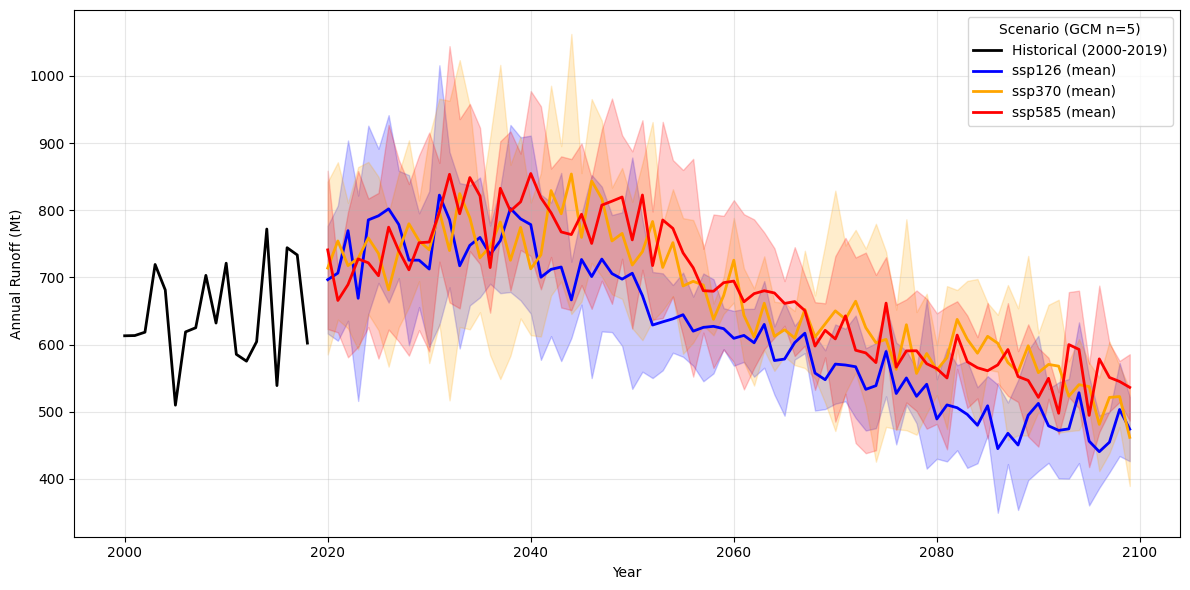

In [10]:
# Finaly plot everything!
plt.figure(figsize=(12, 6))

# Plot historical runoff.
hist_runoff.plot(label='Historical (2000-2019)', color='black', lw=2)

# Plot the scenario based runoff and fill the plot. Idea for plot and code roughly derived from this tutorial https://tutorials.oggm.org/stable/notebooks/tutorials/merge_gcm_runs_and_visualize.html.
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}
for scenario in scenarios:
    runoff_mean.sel(SCENARIO=scenario).plot(
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    plt.fill_between(
        runoff_mean.time,
        runoff_mean.sel(SCENARIO=scenario) - runoff_std.sel(SCENARIO=scenario),
        runoff_mean.sel(SCENARIO=scenario) + runoff_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.2
    )

plt.ylabel('Annual Runoff (Mt)')
plt.xlabel('Year')
plt.title('')# remove title (xarray variables were shown on the title before).
plt.grid(True, alpha=0.3)
plt.legend(title='Scenario (GCM n=5)')
plt.tight_layout()
plt.savefig('Runoff_Overall_2000_2100.png', dpi=300, bbox_inches='tight')
plt.show()

In [11]:

'''''''''''''''''''''''''''''''''''''''''
Table Plot (Percentage of 2000 runoff)

All Variables used


'''''''''''''''''''''''''''''''''''''''''

# Define 5 year intervals from 2020 to 2100
intervals = [
    (2020, 2025), (2025, 2030), (2030, 2035), (2035, 2040),
    (2040, 2045), (2045, 2050), (2050, 2055), (2055, 2060),
    (2060, 2065), (2065, 2070), (2070, 2075), (2075, 2080),
    (2080, 2085), (2085, 2090), (2090, 2095), (2095, 2100)
]

In [12]:
# GSWP_W5E5 derived Baseline runoff (in Mt) in 2000 (from RQ2)
baseline_runoff = 617  

In [13]:
# Initialise  dictionary
interval_change_relative_to_2000 = {interval: {} for interval in intervals}

# Calculate % change for each interval and scenario relative to 2000
for scenario in runoff_mean.SCENARIO.values:
    for interval in intervals:
        start_year, end_year = interval
        try:
            # Get the runoff for the end year from GCM data using nearest matching year
            runoff_end = runoff_mean.sel(SCENARIO=scenario).sel(time=end_year, method='nearest').values.item()
            
            # Calculate the percentage change relative to 2000
            percentage_change = ((runoff_end - baseline_runoff) / baseline_runoff) * 100
            # Store the result
            interval_change_relative_to_2000[interval][scenario] = percentage_change
        except Exception as e:
            print(f"Error processing {scenario} {interval}: {str(e)}")
            interval_change_relative_to_2000[interval][scenario] = np.nan

In [14]:
# Convert dictionary to a DataFrame
df_interval_change_relative_to_2000 = pd.DataFrame.from_dict(interval_change_relative_to_2000, orient='index')

# Round values to 1DP
df_interval_change_relative_to_2000 = df_interval_change_relative_to_2000.round(1)

# Add an average column (skip NaN values in calculation)
df_interval_change_relative_to_2000['Average'] = df_interval_change_relative_to_2000.mean(axis=1, skipna=True).round(1)

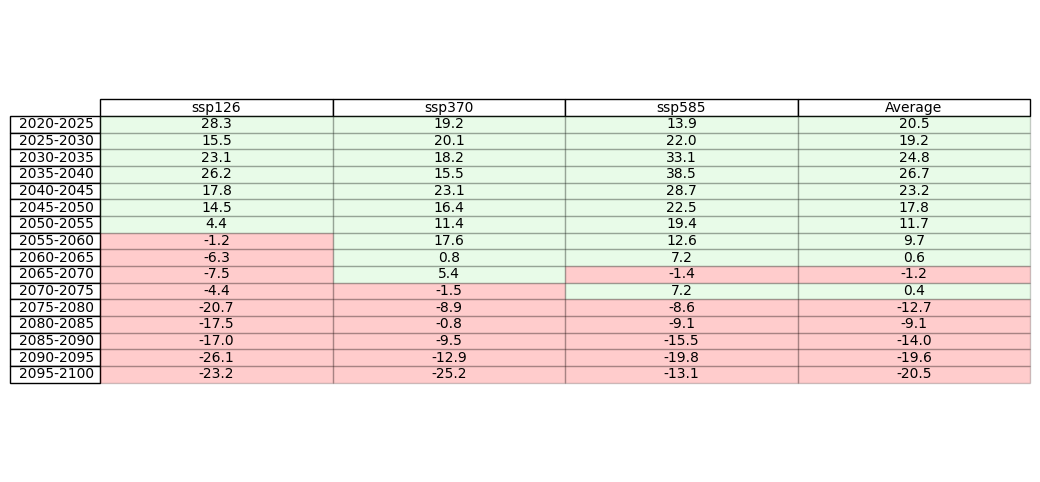

In [15]:
# Plot the table 
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=df_interval_change_relative_to_2000.values,
    colLabels=df_interval_change_relative_to_2000.columns,
    rowLabels=[f"{start}-{end}" for (start, end) in intervals],
    cellLoc='center',
    loc='center'
)

# Style the table cells based on values
for i in range(df_interval_change_relative_to_2000.shape[0]):
    for j in range(df_interval_change_relative_to_2000.shape[1]):
        cell = table[i+1, j]
        value = df_interval_change_relative_to_2000.iloc[i, j]
        if pd.isna(value):
            cell.set_facecolor("lightgray")
        elif value < 0:
            cell.set_facecolor("red")
            cell.set_alpha(0.2)
        else:
            cell.set_facecolor("lightgreen")
            cell.set_alpha(0.2)
# Save the table
plt.savefig('overall_change_relative_to_2000.png', dpi=300, bbox_inches='tight')
plt.show()

In [16]:
'''''''''''''''''''''''''''''''''''''''''
Re run the simulation for melt_on_glacier.



'''''''''''''''''''''''''''''''''''''''''

def process_runoff(ds):
    runoff_vars =['melt_on_glacier']
    ds_runoff = ds[runoff_vars].clip(0) * 1e-9  # Convert to Mt
    return ds_runoff.to_array(dim='vars').sum(dim='vars')


hist_runoff = process_runoff(ds_hist)
gcm_runoff = process_runoff(ds_gcm)

# Calculate statistics
runoff_mean = gcm_runoff.groupby('SCENARIO').mean(dim='run')
runoff_std = gcm_runoff.groupby('SCENARIO').std(dim='run')

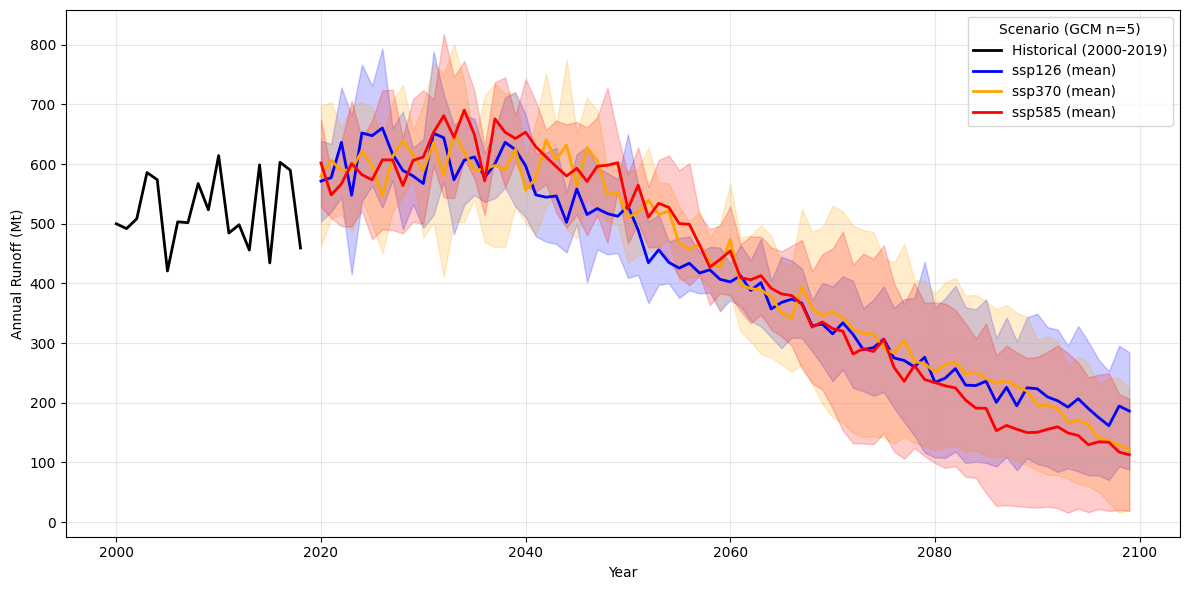

In [17]:
# Finaly plot everything!
plt.figure(figsize=(12, 6))

# Plot historical runoff.
hist_runoff.plot(label='Historical (2000-2019)', color='black', lw=2)

# Plot the scenario based runoff and fill the plot. Idea for plot and code roughly derived from this tutorial https://tutorials.oggm.org/stable/notebooks/tutorials/merge_gcm_runs_and_visualize.html.
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}
for scenario in scenarios:
    runoff_mean.sel(SCENARIO=scenario).plot(
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    plt.fill_between(
        runoff_mean.time,
        runoff_mean.sel(SCENARIO=scenario) - runoff_std.sel(SCENARIO=scenario),
        runoff_mean.sel(SCENARIO=scenario) + runoff_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.2
    )

plt.ylabel('Annual Runoff (Mt)')
plt.xlabel('Year')
plt.title('')# remove title (xarray variables were shown on the title before).
plt.grid(True, alpha=0.3)
plt.legend(title='Scenario (GCM n=5)')
plt.tight_layout()
plt.savefig('Runoff_Melt_On_Glacier_2000_2100.png', dpi=300, bbox_inches='tight')
plt.show()

In [134]:
'''''''''''''''''''''''''''''''''''''''''
Table Plot (Percentage of 2000 runoff)

melt_on_glacier used


'''''''''''''''''''''''''''''''''''''''''

# Define 5 year intervals from 2020 to 2100
intervals = [
    (2020, 2025), (2025, 2030), (2030, 2035), (2035, 2040),
    (2040, 2045), (2045, 2050), (2050, 2055), (2055, 2060),
    (2060, 2065), (2065, 2070), (2070, 2075), (2075, 2080),
    (2080, 2085), (2085, 2090), (2090, 2095), (2095, 2100)
]

In [135]:
# Baseline runoff in 2000 (from RQ2)
baseline_runoff = 503  

In [136]:
# Initialize a dictionary to store the results
interval_change_relative_to_2000 = {interval: {} for interval in intervals}

# Calculate the percentage change for each interval and scenario relative to 2000
for scenario in runoff_mean.SCENARIO.values:
    for interval in intervals:
        start_year, end_year = interval
        try:
            # Get the runoff for the end year from GCM data using nearest matching year
            runoff_end = runoff_mean.sel(SCENARIO=scenario).sel(time=end_year, method='nearest').values.item()
            
            # Calculate the percentage change relative to 2000
            percentage_change = ((runoff_end - baseline_runoff) / baseline_runoff) * 100
            # Store the result
            interval_change_relative_to_2000[interval][scenario] = percentage_change
        except Exception as e:
            print(f"Error processing {scenario} {interval}: {str(e)}")
            interval_change_relative_to_2000[interval][scenario] = np.nan

In [137]:
# Convert the dictionary to a pandas DataFrame
df_interval_change_relative_to_2000 = pd.DataFrame.from_dict(interval_change_relative_to_2000, orient='index')

# Round values to 1 decimal place
df_interval_change_relative_to_2000 = df_interval_change_relative_to_2000.round(1)

# Add an average column (skip NaN values in calculation)
df_interval_change_relative_to_2000['Average'] = df_interval_change_relative_to_2000.mean(axis=1, skipna=True).round(1)

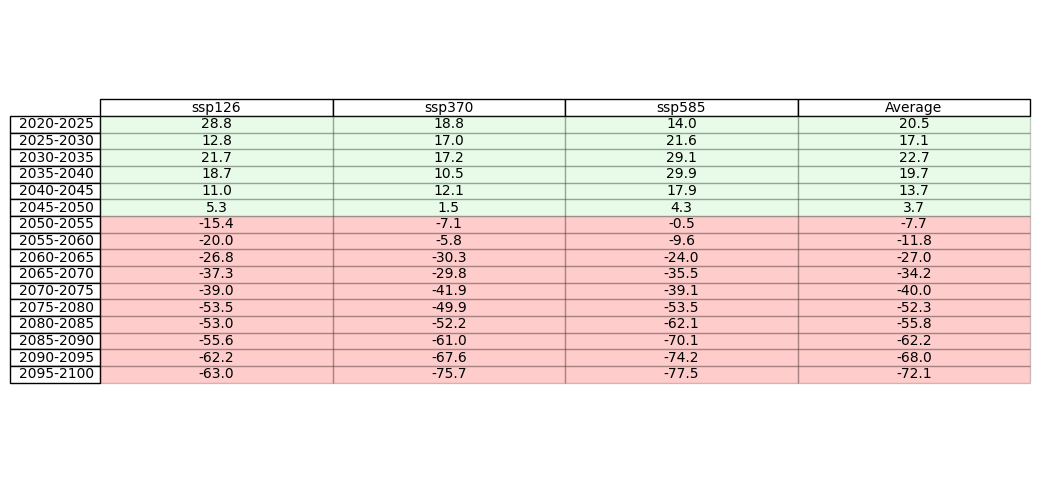

In [138]:
# Plot the table 
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

table = ax.table(
    cellText=df_interval_change_relative_to_2000.values,
    colLabels=df_interval_change_relative_to_2000.columns,
    rowLabels=[f"{start}-{end}" for (start, end) in intervals],
    cellLoc='center',
    loc='center'
)

# Style the table cells based on values
for i in range(df_interval_change_relative_to_2000.shape[0]):
    for j in range(df_interval_change_relative_to_2000.shape[1]):
        cell = table[i+1, j]
        value = df_interval_change_relative_to_2000.iloc[i, j]
        if pd.isna(value):
            cell.set_facecolor("lightgray")
        elif value < 0:
            cell.set_facecolor("red")
            cell.set_alpha(0.2)
        else:
            cell.set_facecolor("lightgreen")
            cell.set_alpha(0.2)
# Save the table
plt.savefig('melt_change_relative_to_2000.png', dpi=300, bbox_inches='tight')
plt.show()

In [139]:


'''''''''''''''''''''''''''''''''''''''''
Re run the simulation for melt_on_glacier+ liq_prcp_on_glaicer.



'''''''''''''''''''''''''''''''''''''''''

def process_runoff(ds):
    runoff_vars =['melt_on_glacier', 'liq_prcp_on_glacier']
    ds_runoff = ds[runoff_vars].clip(0) * 1e-9  # Convert to Mt
    return ds_runoff.to_array(dim='vars').sum(dim='vars')

# Process runoff data
hist_runoff = process_runoff(ds_hist)
gcm_runoff = process_runoff(ds_gcm)

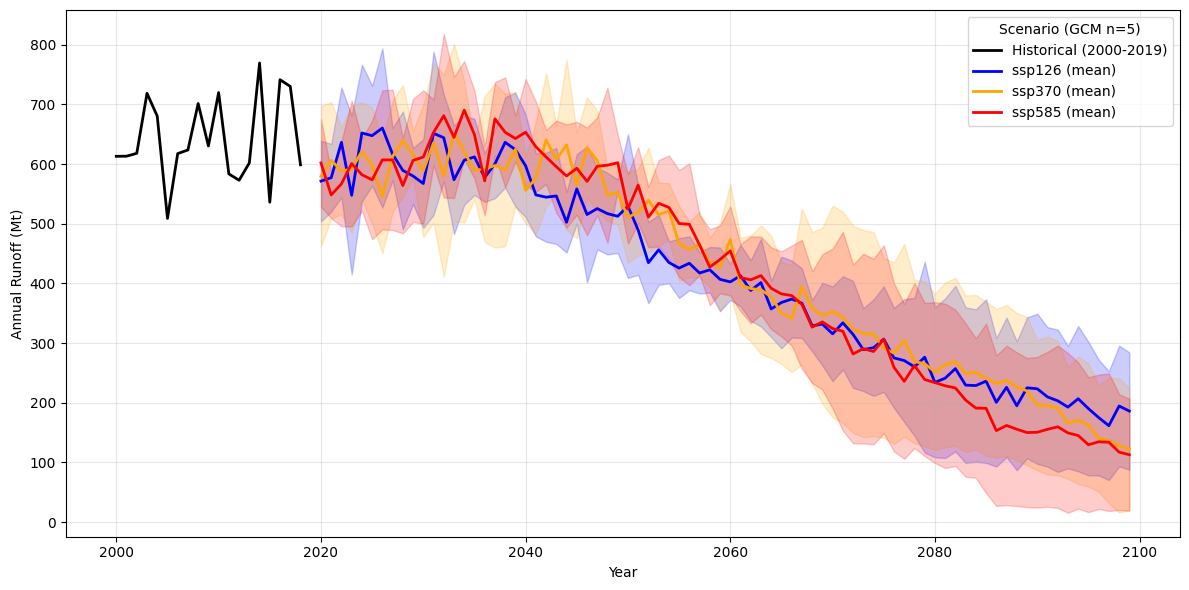

In [140]:
# Finaly plot everything!
plt.figure(figsize=(12, 6))

# Plot historical runoff.
hist_runoff.plot(label='Historical (2000-2019)', color='black', lw=2)

# Plot the scenario based runoff and fill the plot. Idea for plot and code roughly derived from this tutorial https://tutorials.oggm.org/stable/notebooks/tutorials/merge_gcm_runs_and_visualize.html.
color_dict = {'ssp126': 'blue', 'ssp370': 'orange', 'ssp585': 'red'}
for scenario in scenarios:
    runoff_mean.sel(SCENARIO=scenario).plot(
        color=color_dict[scenario],
        label=f'{scenario} (mean)',
        lw=2
    )
    plt.fill_between(
        runoff_mean.time,
        runoff_mean.sel(SCENARIO=scenario) - runoff_std.sel(SCENARIO=scenario),
        runoff_mean.sel(SCENARIO=scenario) + runoff_std.sel(SCENARIO=scenario),
        color=color_dict[scenario],
        alpha=0.2
    )

plt.ylabel('Annual Runoff (Mt)')
plt.xlabel('Year')
plt.title('')# remove title (xarray variables were shown on the title before).
plt.grid(True, alpha=0.3)
plt.legend(title='Scenario (GCM n=5)')
plt.tight_layout()
plt.savefig('Runoff_Melt_On_AndGlacier_2000_2100.png', dpi=300, bbox_inches='tight')
plt.show()

In [141]:

intervals = [
    (2020, 2025), (2025, 2030), (2030, 2035), (2035, 2040),
    (2040, 2045), (2045, 2050), (2050, 2055), (2055, 2060),
    (2060, 2065), (2065, 2070), (2070, 2075), (2075, 2080),
    (2080, 2085), (2085, 2090), (2090, 2095), (2095, 2100)
]

In [142]:
# Baseline runoff in 2000 (from RQ2)
baseline_runoff = 617  # Mt

In [143]:
# Initialize a dictionary to store the results
interval_change_relative_to_2000 = {interval: {} for interval in intervals}

# Calculate the percentage change for each interval and scenario relative to 2000
for scenario in runoff_mean.SCENARIO.values:
    for interval in intervals:
        start_year, end_year = interval
        try:
            # Get the runoff for the end year from GCM data using nearest matching year
            runoff_end = runoff_mean.sel(SCENARIO=scenario).sel(time=end_year, method='nearest').values.item()
            
            # Calculate the percentage change relative to 2000
            percentage_change = ((runoff_end - baseline_runoff) / baseline_runoff) * 100
            # Store the result
            interval_change_relative_to_2000[interval][scenario] = percentage_change
        except Exception as e:
            print(f"Error processing {scenario} {interval}: {str(e)}")
            interval_change_relative_to_2000[interval][scenario] = np.nan

In [144]:
# Convert the dictionary to a pandas DataFrame
df_interval_change_relative_to_2000 = pd.DataFrame.from_dict(interval_change_relative_to_2000, orient='index')

# Round values to 1 decimal place
df_interval_change_relative_to_2000 = df_interval_change_relative_to_2000.round(1)

# Add an average column (skip NaN values in calculation)
df_interval_change_relative_to_2000['Average'] = df_interval_change_relative_to_2000.mean(axis=1, skipna=True).round(1)

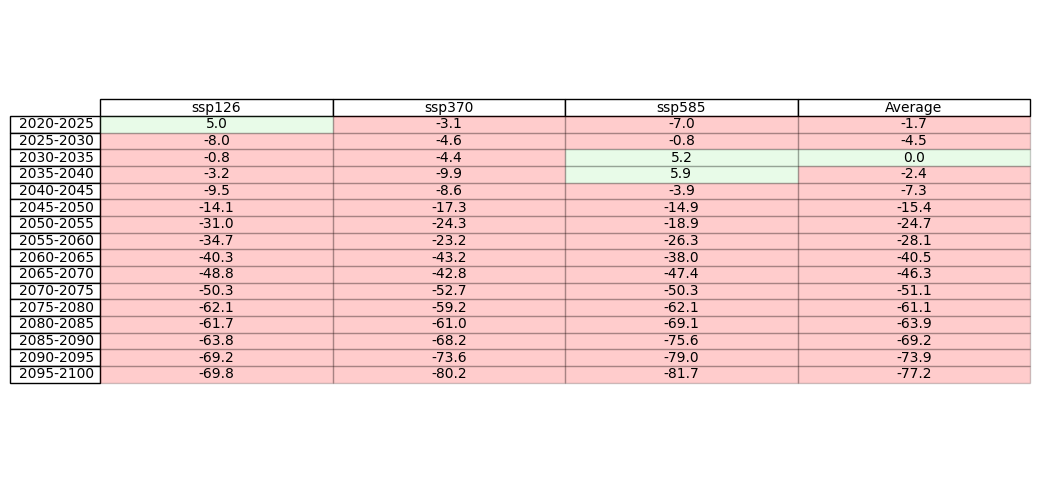

In [145]:
# Plot the table using matplotlib
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(
    cellText=df_interval_change_relative_to_2000.values,
    colLabels=df_interval_change_relative_to_2000.columns,
    rowLabels=[f"{start}-{end}" for (start, end) in intervals],
    cellLoc='center',
    loc='center'
)

# Style the table cells based on values
for i in range(df_interval_change_relative_to_2000.shape[0]):
    for j in range(df_interval_change_relative_to_2000.shape[1]):
        cell = table[i+1, j]
        value = df_interval_change_relative_to_2000.iloc[i, j]
        if pd.isna(value):
            cell.set_facecolor("lightgray")
        elif value < 0:
            cell.set_facecolor("red")
            cell.set_alpha(0.2)
        else:
            cell.set_facecolor("lightgreen")
            cell.set_alpha(0.2)

# Set title

# Save the table
plt.savefig('melt_prcp_change_relative_to_2000.png', dpi=300, bbox_inches='tight')
plt.show()